# 4주차_기계학습과_인식_2

- Preview
- 지도학습
- 선형 회귀
- K-Nearest Neighbors, KNN
- 결정 트리
- 비지도 학습
- K-Means Clustering
- 차원 축소


---

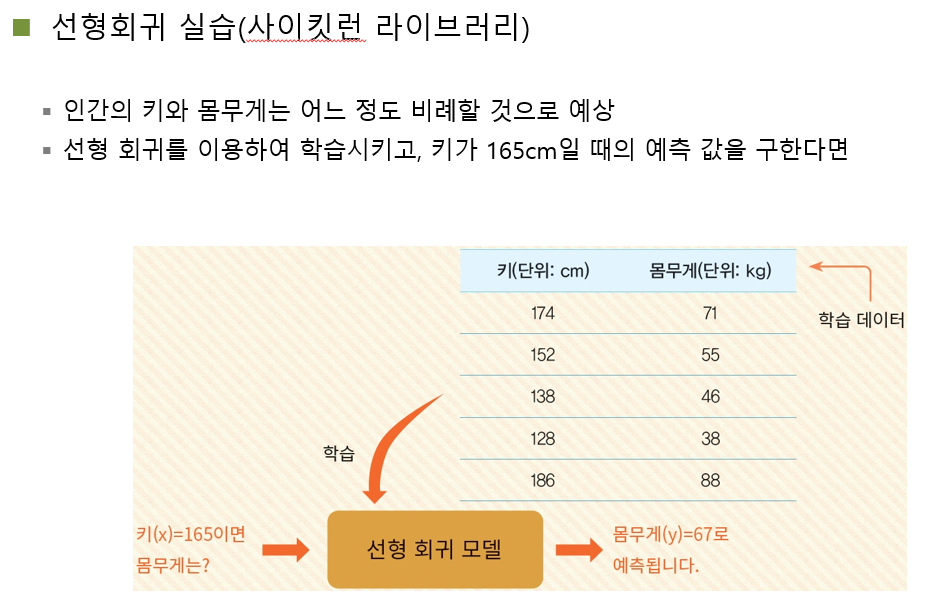

[67.30998637]


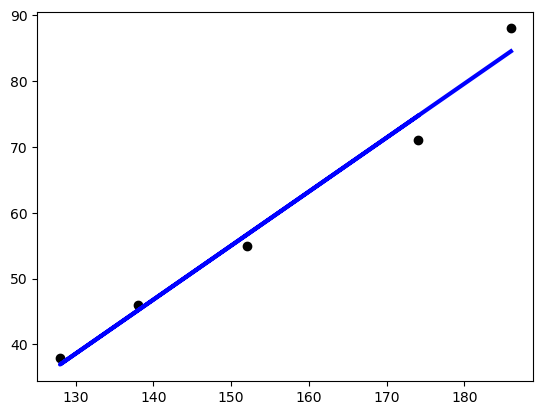

In [1]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 키(독립 변수)를 입력으로, 몸무게(종속 변수)를 예측하는  
# 단순 선형 회귀 모델을 학습하고 시각화하는 예제임.  
# sklearn의 `LinearRegression`을 사용하여 회귀선을 학습하고,  
# 예측 결과를 시각적으로 확인할 수 있도록 산점도 및 회귀선 그래프를 그리는 구조임.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 선형 회귀 모델 객체 생성
# 2단계: 학습 데이터(X, y) 정의 및 모델 학습
# 3단계: 새 입력에 대한 예측 수행
# 4단계: 학습 데이터 산점도 시각화
# 5단계: 회귀선(예측값)을 선 그래프로 시각화
# ------------------------------------------------------------

import matplotlib.pylab as plt  # 시각화를 위한 matplotlib의 pylab 모듈 임포트
from sklearn import linear_model  # 선형 모델 관련 기능을 포함한 모듈 임포트

reg = linear_model.LinearRegression()  
# sklearn의 선형 회귀 모델 객체 생성
# → 단일 독립 변수에 대해 직선 형태의 예측 모델을 학습함

X = [[174], [152], [138], [128], [186]]  
# 독립 변수 X: 키 (단일 특성, 2차원 배열 형식으로 전달 필요)

y = [71, 55, 46, 38, 88]  
# 종속 변수 y: 몸무게 (실제 관측된 결과값)

reg.fit(X, y)  
# 선형 회귀 모델을 X, y 데이터를 이용하여 학습시킴
# → 직선의 기울기(w)와 절편(b)를 내부적으로 계산함

print(reg.predict([[165]]))  
# 키가 165cm일 때 예측된 몸무게 값을 출력

# ------------------------------------------------------------
# [시각화] 학습 데이터와 회귀선 시각화
# ------------------------------------------------------------

plt.scatter(X, y, color='black')  
# 원래의 관측 데이터(X, y)를 산점도로 시각화
# 각 점은 (키, 몸무게)의 관계를 나타냄

y_pred = reg.predict(X)  
# 학습 데이터 X에 대해 예측값(=회귀선 상의 y 값들)을 계산

plt.plot(X, y_pred, color='blue', linewidth=3)  
# 계산된 예측값을 기준으로 회귀선을 선 그래프로 출력
# 파란색 선은 학습된 선형 회귀 모델이 학습 데이터에 적합시킨 직선을 의미

plt.show()  
# 산점도 + 회귀선이 함께 포함된 그래프를 화면에 표시


In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 사이킷런(sklearn)의 당뇨병 데이터셋(load_diabetes)을 기반으로  
# BMI(체질량지수)를 독립 변수로 하고, 혈당 수치를 종속 변수로 하여  
# 선형 회귀(Linear Regression) 모델을 학습하고,  
# 실제 데이터와 회귀선을 함께 시각화하는 예제임.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 당뇨병 데이터셋 로드 및 변수 추출
# 2단계: BMI 데이터를 X, 혈당 데이터를 y로 정의
# 3단계: 선형 회귀 모델 학습
# 4단계: 예측 결과 생성 및 시각화
# ------------------------------------------------------------

from sklearn.datasets import load_diabetes  # 당뇨병 예제 데이터셋 로드 함수 임포트
from sklearn.linear_model import LinearRegression  # 선형 회귀 모델 클래스 임포트
import matplotlib.pyplot as plt  # 시각화를 위한 matplotlib 임포트

# ------------------------------------------------------------
# [1단계] 데이터셋 로드 및 설명 확인
# ------------------------------------------------------------

diabetes = load_diabetes()  
# 사이킷런이 제공하는 당뇨병 진단 예제 데이터셋을 로드
# 각 환자에 대해 10개의 지표(특성)가 포함됨 (예: 나이, BMI, 혈압 등)

print(diabetes.DESCR)  
# 데이터셋에 대한 전반적인 설명을 출력 (특성 의미, 출처 등 포함)

# ------------------------------------------------------------
# [2단계] BMI (Body Mass Index)와 목표 변수(혈당 수치) 추출
# ------------------------------------------------------------

X = diabetes.data[:, 2].reshape(-1, 1)  
# 입력 변수 X로 BMI(BMI는 3번째 열, 인덱스 2)를 추출
# reshape(-1, 1): sklearn 모델에 맞게 2차원 배열로 변환

y = diabetes.target.reshape(-1, 1)  
# 종속 변수 y로 혈당 수치를 지정
# reshape(-1, 1): 2차원 배열로 변환하여 시각화 및 계산 호환성 확보


# 📌 reshape(-1,1) 왜 필요한가요?
# 사이킷런(Sklearn)의 모델은 대부분 **2차원 배열(행: 샘플 수, 열: 특성 수)**을 입력으로 기대.
# 하지만 아래와 같이 X = diabetes.data[:, 2]처럼 슬라이싱하면 1차원 배열이 됨.

# X.shape  →  (442,)     ← (샘플 수,)
# ➡ 이건 442개의 값은 있지만, 특성이 몇 개인지는 명시되어 있지 않음 → 학습 시 오류 가능

# 그래서 이렇게 바꿔야 함:
# X = diabetes.data[:, 2].reshape(-1, 1)  # (-1: 자동 계산, 1: 열 1개)
# X.shape → (442, 1)
# ➡ 이제 442개의 샘플, 각 샘플은 1개의 특성을 가진 2차원 배열이 되어 모델 입력으로 적합해짐.

# ------------------------------------------------------------
# [3단계] 선형 회귀 모델 학습
# ------------------------------------------------------------

model = LinearRegression()  
# 선형 회귀 모델 객체 생성

model.fit(X, y)  
# BMI(X)를 사용하여 혈당 수치(y)를 예측하도록 모델을 학습

# ------------------------------------------------------------
# [4단계] 예측 및 시각화
# ------------------------------------------------------------

y_pred = model.predict(X)  
# 학습된 모델을 통해 입력 X(BMI)에 대한 예측값(혈당 수치)을 생성

plt.scatter(X, y, alpha=0.5)  
# 실제 데이터 (X, y)를 산점도로 시각화
# alpha=0.5: 점의 투명도 조절 (겹쳐 보이는 문제 방지)

plt.plot(X, y_pred, color='red')  
# 학습된 선형 회귀 모델이 예측한 회귀선을 빨간색 선으로 표시

plt.title('BMI vs. Sugar')  # 그래프 제목 설정
plt.xlabel('BMI')           # x축 이름 설정
plt.ylabel('Sugar')         # y축 이름 설정

plt.show()  
# 전체 그래프를 화면에 표시


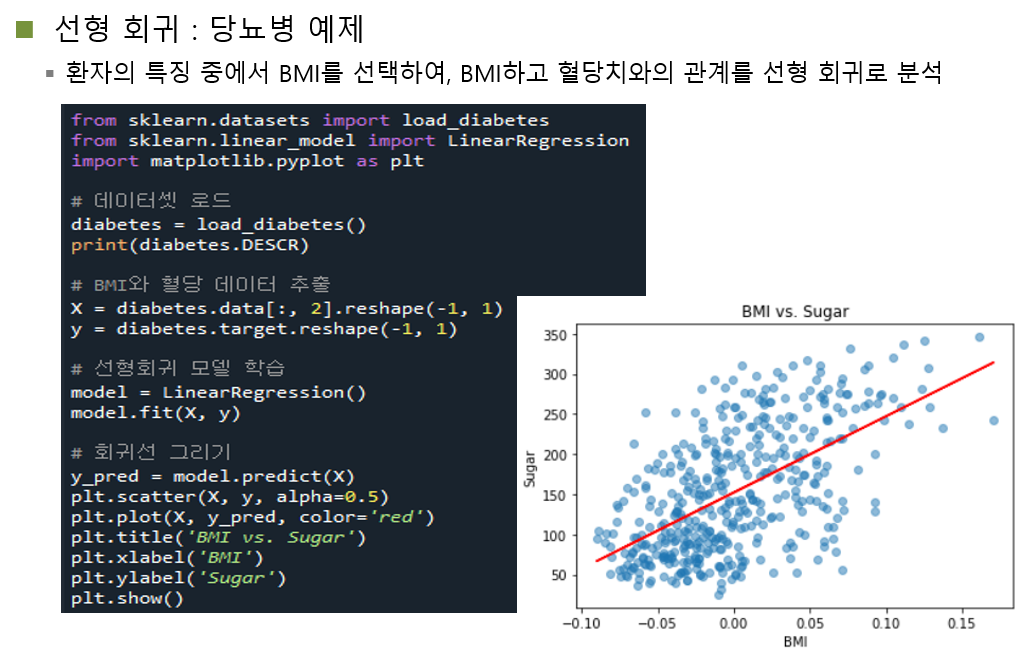

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 sklearn의 당뇨병 데이터셋에서 **BMI(체질량지수)** 하나의 특성만 추출하여,  
# 선형 회귀 모델을 학습한 뒤, 테스트 데이터에 대한 예측 결과를 시각적으로 출력하는 예제임.
# 학습/테스트 분리는 train_test_split을 사용하며, 결과는 산점도 및 회귀선으로 시각화함.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 당뇨병 데이터셋 로드 및 BMI 피처만 추출
# 2단계: 학습/테스트 데이터셋 분할
# 3단계: 선형 회귀 모델 학습
# 4단계: 테스트셋에 대한 예측 수행
# 5단계: 산점도 + 회귀선 시각화
# ------------------------------------------------------------

import matplotlib.pylab as plt  # 시각화 출력을 위한 matplotlib 모듈 임포트
import numpy as np  # 수치 연산 및 배열 처리 기능 제공 모듈 임포트
from sklearn import datasets, linear_model  # 데이터셋과 선형 회귀 모델 모듈 임포트

# ------------------------------------------------------------
# [1단계] 데이터 로드 및 BMI 특성 추출
# ------------------------------------------------------------

diabetes_X, diabetes_y = datasets.load_diabetes(return_X_y=True)  
# 당뇨병 데이터셋을 (X, y) 형태로 로드
# diabetes_X: 입력 특성 (442×10), diabetes_y: 목표값(혈당 수치)

print(diabetes_X)  
# 전체 특성 행렬 출력

print(diabetes_X.shape)  
# diabetes_X의 행렬 크기 출력 → (442, 10)

# BMI 특성(2번째 열)을 추출하고 2차원 배열로 변환
diabetes_X_new = diabetes_X[:, np.newaxis, 2]  
# np.newaxis를 사용하여 (442,) → (442, 1) 형태로 reshape

# | 코드                          | 결과 차원 | 의미                                       |
# |-------------------------------|------------|--------------------------------------------|
# | `diabetes_X[:, 2]`            | (442,)     | 세 번째 특성만 추출한 1차원 벡터           |
# | `diabetes_X[:, np.newaxis, 2]`| (442, 1)   | 세 번째 특성을 2차원 컬럼 벡터로 변환      |


print(diabetes_X_new)  
# BMI 하나만 추출된 특성 행렬 출력

print(diabetes_X_new.shape)  
# BMI 특성 행렬의 크기 출력 → (442, 1)

# ------------------------------------------------------------
# [2단계] 학습/테스트 세트 분할
# ------------------------------------------------------------

from sklearn.model_selection import train_test_split  # 데이터 분할 함수 임포트

X_train, X_test, y_train, y_test = train_test_split(
    diabetes_X_new,  # 입력 특성 (BMI만 사용)
    diabetes_y,      # 목표값 (혈당 수치)
    test_size=0.1,   # 전체 데이터 중 10%를 테스트용으로 사용
    random_state=0   # 재현 가능한 분할을 위한 시드 고정
)

# ------------------------------------------------------------
# [3단계] 선형 회귀 모델 학습
# ------------------------------------------------------------

regr = linear_model.LinearRegression()  
# 선형 회귀 모델 객체 생성

regr.fit(X_train, y_train)  
# 훈련 데이터를 사용하여 회귀 모델 학습 수행

# ------------------------------------------------------------
# [4단계] 테스트 데이터 예측
# ------------------------------------------------------------

y_pred = regr.predict(X_test)  
# 학습된 모델을 사용하여 테스트 데이터(BMI)에 대한 혈당 예측 수행

# ------------------------------------------------------------
# [5단계] 시각화 출력
# ------------------------------------------------------------

plt.scatter(X_test, y_test, color='black')  
# 테스트 데이터의 실제 값(y_test)을 산점도로 출력 (실제 관측값)

plt.plot(X_test, y_pred, color='blue', linewidth=3)  
# 예측값(y_pred)을 선형 회귀선으로 시각화

plt.show()  
# 산점도 + 회귀선 그래프를 화면에 출력


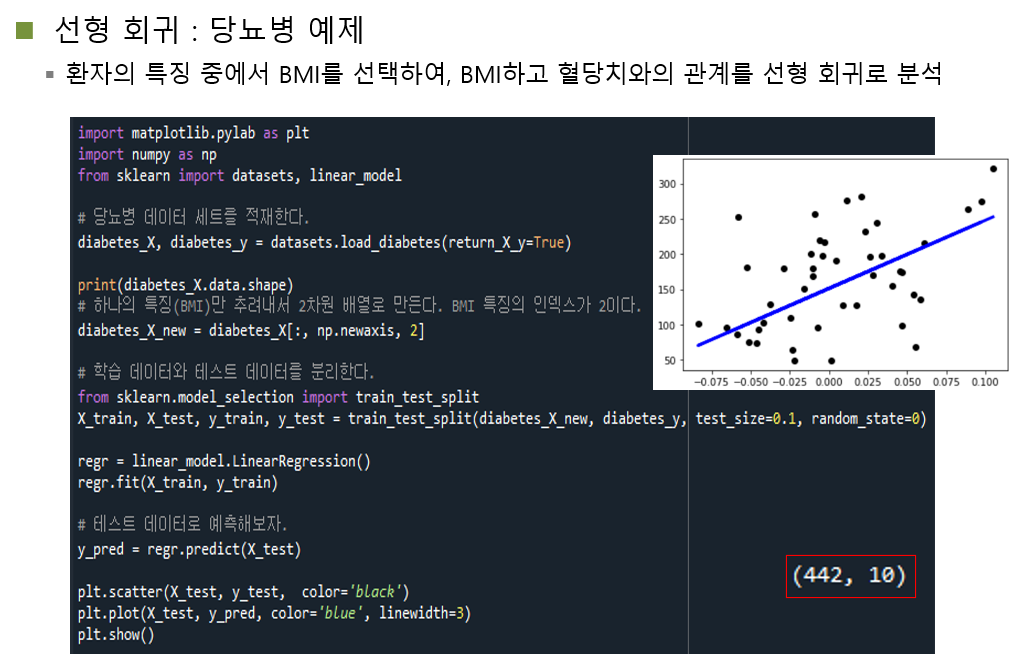

| 구분             | 첫 번째 코드                           | 두 번째 코드                                     |
|------------------|----------------------------------------|--------------------------------------------------|
| 데이터 분할       | 전체 데이터를 그대로 사용              | 학습/테스트 세트로 분리 (`train_test_split`)     |
| 모델 학습 대상    | 전체 442개 샘플 사용                   | 학습용 90% (397개)만 사용                        |
| 예측 대상         | 전체 데이터에 대해 예측                | 테스트 데이터에 대해 예측                        |
| 시각화 대상       | 전체 데이터 + 전체 예측 결과           | 테스트 데이터 + 테스트 예측 결과                 |
| X 추출 방식       | `reshape(-1, 1)` 사용                  | `np.newaxis` 사용                                |
| 정확도 평가       | 없음                                   | 없음 (단순 시각화만)                             |
| 현업적 의미       | 모델 구조 확인 중심 예제               | 일반적인 ML 워크플로우 구조 반영                 |


In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 사이킷런(sklearn)의 붓꽃(iris) 데이터셋을 기반으로,  
# K-최근접 이웃(K-Nearest Neighbors, KNN) 알고리즘을 사용하여  
# 분류 모델을 학습하고, 테스트 데이터셋에 대해 예측 정확도를 계산하는 실습 코드임.

# 핵심 아이디어	
# 새로운 데이터를 예측할 때, 훈련 데이터 중 가장 가까운 K개의 이웃을 찾고, 
# 그 이웃들의 **다수결(분류)** 또는 **평균값(회귀)**을 예측값으로 사용함

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 데이터셋 로드 및 입력(X), 출력(y) 분리
# 2단계: 학습/테스트 세트 분할 (8:2 비율)
# 3단계: KNN 분류기 모델 정의 및 학습 수행
# 4단계: 테스트 데이터 예측 수행
# 5단계: 정확도 계산 및 출력
# ------------------------------------------------------------

from sklearn.datasets import load_iris  # 아이리스 데이터셋 로드 함수 임포트
iris = load_iris()  
# 아이리스 데이터셋 로드
# iris.data → 입력 특성(꽃받침, 꽃잎 길이/너비)
# iris.target → 품종 레이블(0, 1, 2)

from sklearn.model_selection import train_test_split  # 데이터 분할 함수 임포트

# ------------------------------------------------------------
# [1단계] 입력(X)과 출력(y) 데이터 정의
# ------------------------------------------------------------

X = iris.data  
# 입력 데이터 X 정의 (특성: 4개)

y = iris.target  
# 출력 레이블 y 정의 (0: setosa, 1: versicolor, 2: virginica)

# ------------------------------------------------------------
# [2단계] 학습/테스트 데이터 분할
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=4
)  
# 전체 데이터를 학습 80%, 테스트 20%로 분할
# random_state로 분할 결과 고정 가능

print(X_train.shape)  # 학습 데이터 입력 형태 출력 (예: (120, 4))
print(X_test.shape)   # 테스트 데이터 입력 형태 출력 (예: (30, 4))

# ------------------------------------------------------------
# [3단계] KNN 분류기 학습
# ------------------------------------------------------------

from sklearn.neighbors import KNeighborsClassifier  # KNN 모델 클래스 임포트
from sklearn import metrics  # 모델 성능 평가 모듈 임포트

knn = KNeighborsClassifier(n_neighbors=6)  
# 최근접 이웃 수(k)를 6으로 설정한 KNN 분류기 객체 생성

knn.fit(X_train, y_train)  
# 학습 데이터를 이용하여 KNN 분류기 모델 학습 수행

# ------------------------------------------------------------
# [4단계] 테스트 데이터 예측
# ------------------------------------------------------------

y_pred = knn.predict(X_test)  
# 테스트 입력 데이터를 바탕으로 품종 예측 수행

# ------------------------------------------------------------
# [5단계] 정확도 평가
# ------------------------------------------------------------

scores = metrics.accuracy_score(y_test, y_pred)  
# 실제 정답(y_test)과 예측 결과(y_pred)를 비교하여 정확도 계산

print(scores)  
# 모델의 최종 정확도 출력 (예: 0.9666 → 96.66%)





(120, 4)
(30, 4)
0.9666666666666667


In [10]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 sklearn의 붓꽃(iris) 데이터셋을 기반으로  
# K-최근접 이웃(KNN) 분류 모델을 학습한 후,  
# 모델이 학습하지 않은 새로운 데이터 샘플에 대해  
# 어떤 붓꽃 품종(setosa, versicolor, virginica)에 속하는지를 예측하는 실습 예제입니다.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: iris 데이터셋 로드 및 입력(X), 출력(y) 정의
# 2단계: 학습/테스트용 데이터 분할 (80:20 비율)
# 3단계: KNN 분류기 학습 (전체 데이터로 학습함)
# 4단계: 새로운 데이터 샘플 제시 및 품종 예측
# 5단계: 예측된 클래스 번호를 이름으로 변환하여 출력
# ------------------------------------------------------------

from sklearn.datasets import load_iris  # 붓꽃 데이터셋 로딩 함수 임포트
iris = load_iris()  # 데이터셋을 로드하여 변수에 저장

from sklearn.model_selection import train_test_split  # 데이터 분할 함수 임포트

# ------------------------------------------------------------
# [1단계] 입력(X), 출력(y) 설정
# ------------------------------------------------------------

X = iris.data  # 입력 변수: 꽃받침, 꽃잎의 길이와 너비 (총 4개 특성)
y = iris.target  # 출력 변수: 각 샘플이 속한 붓꽃 품종 (0~2 정수값)

# ------------------------------------------------------------
# [2단계] 학습/테스트 세트 분할
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=4
)
# 전체 데이터를 80% 학습용, 20% 테스트용으로 분할
# random_state를 고정하여 실행 결과 재현 가능

print(X_train.shape)  # 학습 데이터의 샘플 수와 특성 수를 출력 (예: (120, 4))

# ------------------------------------------------------------
# [3단계] KNN 분류기 정의 및 학습
# ------------------------------------------------------------

from sklearn.neighbors import KNeighborsClassifier  # KNN 분류기 클래스 임포트

knn = KNeighborsClassifier(n_neighbors=5)  # 최근접 이웃 수 k=5로 설정한 KNN 분류기 생성

knn.fit(X, y)  # 전체 데이터를 사용하여 KNN 분류기 학습 수행
# ※ 주의: 위에서 학습/테스트로 나눈 데이터를 사용하지 않고 전체 데이터(X, y)를 학습에 사용하고 있음

# ------------------------------------------------------------
# [4단계] 새로운 데이터 샘플에 대한 예측
# ------------------------------------------------------------

classes = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}  
# 숫자 클래스(0, 1, 2)를 품종 이름으로 매핑하기 위한 딕셔너리 정의

x_new = [
    [3, 4, 5, 2],  # 샘플 1: 네 개의 특성 값을 가지는 새로운 샘플
    [5, 4, 2, 2]   # 샘플 2
]  # 아직 모델이 학습에 사용하지 않은 새로운 입력 데이터 정의

y_predict = knn.predict(x_new)  # 위 새 샘플에 대해 예측 수행 → 클래스 번호 리스트 반환

# ------------------------------------------------------------
# [5단계] 예측 결과를 품종 이름으로 출력
# ------------------------------------------------------------

print(classes[y_predict[0]])  # 첫 번째 샘플의 예측 결과를 이름으로 출력
print(classes[y_predict[1]])  # 두 번째 샘플의 예측 결과를 이름으로 출력


(120, 4)
versicolor
setosa


In [8]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 사이킷런(sklearn)의 붓꽃(iris) 데이터셋을 이용하여  
# SVM(Support Vector Machine) 분류기를 학습하고,  
# 테스트 데이터에 대한 예측을 수행한 뒤, 정확도를 계산하는 분류 실습 예제임.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: iris 데이터셋 로드 및 입력(X), 출력(y) 분리
# 2단계: 학습 데이터와 테스트 데이터 분할 (80:20)
# 3단계: SVM 모델 생성 및 학습
# 4단계: 테스트 데이터에 대한 예측 수행
# 5단계: 정확도 평가 및 출력
# ------------------------------------------------------------

from sklearn.datasets import load_iris  # 붓꽃 데이터셋 로드 함수 임포트
iris = load_iris()  
# sklearn의 내장 붓꽃 데이터셋 로드
# iris.data → 입력 특성 (꽃받침, 꽃잎 길이/너비)
# iris.target → 품종 라벨 (0: setosa, 1: versicolor, 2: virginica)

from sklearn.model_selection import train_test_split  # 데이터 분할 함수 임포트

# ------------------------------------------------------------
# [1단계] 입력(X)과 출력(y) 정의
# ------------------------------------------------------------

X = iris.data  # 입력값 정의 (4개의 꽃 특성)
y = iris.target  # 출력값 정의 (0, 1, 2 → 품종 번호)

# ------------------------------------------------------------
# [2단계] 학습/테스트 데이터 분할
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=4
)  
# 전체 데이터셋을 학습용 80%, 테스트용 20% 비율로 분할
# random_state는 무작위 분할의 일관성을 위해 고정

print(X_train.shape)  # 학습 데이터 크기 출력
print(X_test.shape)   # 테스트 데이터 크기 출력

# ------------------------------------------------------------
# [3단계] SVM 모델 학습
# ------------------------------------------------------------

from sklearn import svm  # SVM 알고리즘 모듈 임포트
from sklearn import metrics  # 모델 평가 함수 모듈 임포트

svc = svm.SVC(gamma=0.1, C=5)  
# SVC(Support Vector Classifier) 객체 생성
# gamma: RBF 커널에서의 감쇠 계수 (작을수록 부드러운 경계)
# C: 오차 허용 범위 제어 (클수록 학습 데이터에 과적합할 가능성 ↑)

svc.fit(X_train, y_train)  
# 학습 데이터로 SVM 모델 학습 수행

# ------------------------------------------------------------
# [4단계] 테스트 데이터 예측
# ------------------------------------------------------------

y_pred = svc.predict(X_test)  
# 학습된 모델을 사용하여 테스트 데이터에 대한 품종 예측 수행

# ------------------------------------------------------------
# [5단계] 정확도 평가
# ------------------------------------------------------------

scores = metrics.accuracy_score(y_test, y_pred)  
# 실제 라벨과 예측 결과를 비교하여 정확도 계산

print(scores)  
# 정확도(0~1)를 출력 (예: 0.9666 → 약 96.66% 정확도)


(120, 4)
(30, 4)
0.9666666666666667


In [13]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 사이킷런의 iris(붓꽃) 데이터셋을 활용하여
# SVM(Support Vector Machine) 분류기를 학습시키고,  
# 학습된 모델을 기반으로 테스트 데이터 및 새로운 데이터 샘플의 품종을 예측하는 과정을 포함함.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 데이터셋 로드 및 입력(X), 출력(y) 정의
# 2단계: 학습용/테스트용 데이터셋 분할 (train_test_split)
# 3단계: SVM 분류 모델(SVC) 객체 생성 및 전체 데이터로 학습
# 4단계: 학습된 모델로 테스트 데이터에 대해 예측 수행
# 5단계: 예측된 클래스 번호를 이름으로 변환하여 출력
# ------------------------------------------------------------

from sklearn.datasets import load_iris  # 아이리스 데이터셋 로드를 위한 함수 임포트
iris = load_iris()  # iris 데이터셋을 로드하고 변수 iris에 저장

from sklearn.model_selection import train_test_split  # 데이터 분할 함수 임포트

# 입력 변수 X와 출력 변수 y를 설정
X = iris.data  # 입력값 X에 모든 특성(꽃받침 길이, 꽃잎 너비 등)을 저장
y = iris.target  # 출력값 y에 품종 라벨(0, 1, 2)을 저장

# 전체 데이터를 학습 80%, 테스트 20% 비율로 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)
# random_state=4는 데이터 분할 결과를 고정하여 재현성을 확보하기 위함

print(X_train.shape)  # 학습용 데이터의 행과 열 구조(샘플 수 × 특성 수)를 출력

from sklearn import svm  # SVM 분류 모델을 위한 모듈 임포트

svc = svm.SVC(gamma=0.1, C=5)  # SVC(Support Vector Classifier) 객체를 생성
# gamma=0.1은 RBF 커널의 곡률을 조절하는 하이퍼파라미터 설정
# C=5는 오차 허용 범위에 대한 규제 강도 설정

svc.fit(X, y)  # 전체 iris 데이터를 이용하여 분류기 학습 수행
# (주의: 앞서 분할한 X_train, y_train이 아닌 전체 데이터 사용)

# 클래스 인덱스를 실제 품종 이름으로 매핑하는 딕셔너리 생성
classes = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}

# 예측에 사용할 새로운 샘플 2개를 정의
x_new = [
    [3, 4, 5, 2],  # 꽃받침/꽃잎의 길이/너비 정보를 갖는 샘플 1
    [5, 4, 2, 2]   # 샘플 2
]

y_predict = svc.predict(X_test)  # 테스트 데이터셋 X_test에 대한 품종 예측 수행
# (주의: 여기서 x_new가 아닌 X_test에 대해 예측을 수행함)

# 예측된 첫 번째 결과의 클래스 번호를 이름으로 변환하여 출력
print(classes[y_predict[0]])  # 예: 'setosa'

# 예측된 두 번째 결과의 클래스 번호를 이름으로 변환하여 출력
print(classes[y_predict[1]])  # 예: 'versicolor'

print("\n------------------------------\n")

y_predict = svc.predict(x_new)

print(classes[y_predict[0]])
print(classes[y_predict[1]])



(120, 4)
virginica
setosa

------------------------------

virginica
setosa


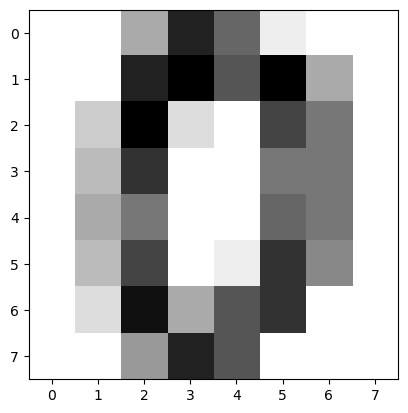

0.9833333333333333


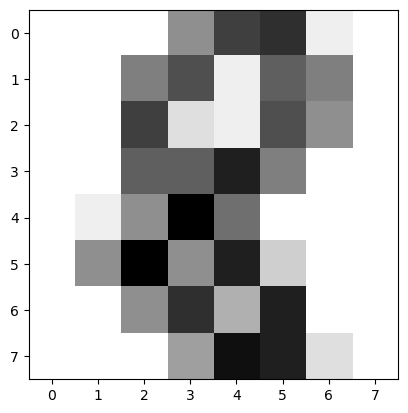

[8]


In [16]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 사이킷런의 `digits` 손글씨 숫자 이미지 데이터셋을 사용하여,
# KNN(K-Nearest Neighbors) 분류기를 학습시키고,
# 테스트 데이터에 대한 예측 정확도를 평가하며,
# 실제 이미지와 예측 결과를 시각적으로 확인하는 예제임.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: digits 이미지 데이터셋 로드 및 시각화
# 2단계: 이미지 데이터를 벡터화하고 학습/테스트 데이터 분할
# 3단계: KNN 분류기 학습 및 예측 수행
# 4단계: 정확도 평가
# 5단계: 테스트 이미지 출력 및 예측 결과 확인
# ------------------------------------------------------------

import matplotlib.pyplot as plt  # 이미지 시각화를 위한 matplotlib 모듈 임포트
from sklearn import datasets, metrics  # 데이터셋 및 평가 도구 임포트
from sklearn.model_selection import train_test_split  # 학습/테스트 분할 함수 임포트

digits = datasets.load_digits()  
# 손글씨 숫자(0~9) 이미지 데이터셋 로드
# digits.images: 8x8 픽셀 이미지 배열, digits.target: 정답 숫자 라벨

plt.imshow(digits.images[0], cmap=plt.cm.gray_r, interpolation='nearest')  
# 0번째 샘플 이미지를 흑백 톤으로 화면에 출력
plt.show()  
# 시각화된 이미지 표시

n_samples = len(digits.images)  
# 전체 이미지 샘플 개수를 n_samples 변수에 저장

data = digits.images.reshape((n_samples, -1))  
# 8×8 이미지 데이터를 1차원(64차원) 벡터로 평탄화하여 벡터 형태의 입력값으로 변환

X_train, X_test, y_train, y_test = train_test_split(
    data, digits.target, test_size=0.2)  
# 전체 데이터셋을 학습용 80%, 테스트용 20% 비율로 분할

from sklearn.neighbors import KNeighborsClassifier  # KNN 분류기 임포트

knn = KNeighborsClassifier(n_neighbors=6)  
# KNN 분류기 객체 생성 (k=6으로 설정 → 가장 가까운 6개 이웃 참조)

knn.fit(X_train, y_train)  
# 학습 데이터(X_train, y_train)를 사용하여 KNN 모델 학습 수행

# 테스트 데이터로 모델 예측 수행
y_pred = knn.predict(X_test)  
# 테스트 샘플들(X_test)에 대한 예측 결과를 y_pred에 저장

# 예측 결과와 실제 정답 간의 정확도 계산
scores = metrics.accuracy_score(y_test, y_pred)  
# accuracy_score 함수를 사용하여 정확도(정답 비율)를 계산

print(scores)  
# 모델의 전체 테스트 정확도 출력

# ------------------------------------------------------------
# 예측 확인을 위해 테스트 이미지 중 하나를 다시 시각화
# ------------------------------------------------------------

plt.imshow(X_test[10].reshape(8,8), cmap=plt.cm.gray_r, interpolation='nearest')  
# 테스트 데이터 중 11번째 샘플 이미지를 8x8 형태로 복원하여 시각화

plt.show()  
# 위 이미지를 화면에 출력

y_pred = knn.predict([X_test[10]])  
# 해당 테스트 샘플 하나에 대해 예측 수행
# 입력값은 반드시 2차원 배열 형태여야 함 → [X_test[10]]

print(y_pred)  
# 예측된 숫자 라벨 출력 (예: [3])

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 결정 트리 분류기(DecisionTreeClassifier)가  
# 간단한 훈련 데이터를 기반으로 학습한 뒤,  
# **훈련에 포함되지 않았던 새로운 데이터([2,2])**에 대해서도 예측을 수행할 수 있음을 보여주는 예제임.

# 이를 통해 결정 트리가 학습한 **규칙 기반 분할 구조**가  
# 훈련 범위 밖의 데이터(extrapolation)에도 적용됨을 설명함.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 간단한 2차원 입력 데이터와 라벨 정의
# 2단계: 결정 트리 분류기 객체 생성 및 학습 수행
# 3단계: 새로운 입력에 대한 예측 수행
# 4단계: 훈련 데이터 범위 외부에서의 분류 가능성 시각화
# ------------------------------------------------------------

from sklearn import tree  # 결정 트리 분류기 클래스 임포트

X = [[0, 0], [1, 1]]  
# 입력 데이터 정의 (2차원 벡터 2개로 구성된 간단한 예제)
# 첫 번째 샘플은 (0,0), 두 번째 샘플은 (1,1)

y = [0, 1]  
# 각 입력 벡터에 대한 클래스 라벨 설정
# (0,0)은 클래스 0, (1,1)은 클래스 1로 정의

clf = tree.DecisionTreeClassifier()  
# 결정 트리 분류기 객체 생성
# 기본 설정: 정보 이득 기반의 이진 트리 구조

clf = clf.fit(X, y)  
# 정의된 입력 X와 정답 y를 바탕으로 결정 트리 학습 수행
# 훈련 샘플 수가 작더라도 규칙 기반 트리 구조는 완성됨

y_pred = clf.predict([[2., 2.]])  
# 훈련 범위 밖의 새로운 입력 (2.0, 2.0)에 대한 예측 수행
# → 학습 데이터에는 없지만, 트리의 분할 기준에 따라 예측 가능

print(y_pred)  
# 예측 결과 출력 (예: [1])
# → (2.0, 2.0)은 [1, 1]과 같은 리프 노드로 분류되었음을 의미함

# ------------------------------------------------------------
# [설명 주석: extrapolation(훈련 외 범위 예측)]
# ------------------------------------------------------------

# [2, 2]는 학습에 사용되지 않은 데이터임
# 하지만 결정 트리는 훈련 중 생성한 분할 기준(예: x1 > 0.5 and x2 > 0.5)을 이용하여
# 이 입력을 기존 트리의 리프 노드 중 하나로 연결함

# 이는 결정 트리가 "훈련 샘플만 외운 것"이 아니라,
# 입력 공간을 분할하는 **규칙 기반 분류기**로서 일반화 구조를 가지고 있음을 보여줌

# 다만, 훈련 샘플이 매우 작거나 불균형할 경우,
# 이러한 일반화는 과적합(overfitting) 또는 오류로 이어질 수 있음


# --------------------------------------------------------

# 일반화 (Generalization):
# 훈련 데이터와 유사한 분포의 테스트 데이터를 예측할 수 있음.

# 외삽 (Extrapolation):
# 훈련 데이터의 범위를 넘어선 입력에 대해 예측하는 것.
# → 결정 트리, 특히 랜덤 포레스트 등은 외삽에 약함.
# → 선형 회귀와 같이 수식 기반 모델은 제한적으로 외삽 가능하지만 여전히 위험.


[1]


| 항목 | 답변 |
|------|------|
| 오류는 과소적합을 의미하나요? | ❌ 아니며, 과적합으로 인한 일반화 실패까지 포함한 넓은 개념입니다. |
| 학습하지 않은 입력([2,2])에 대한 예측은 신뢰할 수 있나요? | ⚠️ 보수적으로 말하면 신뢰할 수 없습니다. 데이터 분포나 수가 충분하지 않기 때문입니다. |
| 학습 외 범위 예측이 의미 있을 때는? | ✅ 트리가 충분한 데이터로 다양한 구간을 잘 학습했을 때, 또는 예측 값이 논리적으로 설명 가능할 때입니다. |


In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 사이킷런의 붓꽃(Iris) 데이터셋을 사용하여  
# 결정 트리 분류기(DecisionTreeClassifier)를 학습한 뒤,  
# 학습 데이터와 테스트 데이터에 대한 분류 정확도를 평가하고,  
# 학습된 결정 트리 구조를 시각화하는 코드임.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 데이터셋 로드 및 입력/출력 분리
# 2단계: 학습/테스트 데이터 분할
# 3단계: 결정 트리 모델 학습
# 4단계: 학습 데이터에 대한 정확도 평가
# 5단계: 테스트 데이터에 대한 정확도 평가
# 6단계: 학습된 결정 트리 시각화
# ------------------------------------------------------------

from sklearn import datasets  # 데이터셋 로딩 기능 임포트
from sklearn.metrics import accuracy_score  # 정확도 평가 함수 임포트
from sklearn.model_selection import train_test_split  # 학습/테스트 분할 함수 임포트
from sklearn.tree import DecisionTreeClassifier  # 결정 트리 분류기 임포트

iris = datasets.load_iris()  # sklearn에서 제공하는 iris(붓꽃) 데이터셋 로드

X, y = iris.data, iris.target  
# X: 입력 피처 (꽃받침 길이/너비, 꽃잎 길이/너비)
# y: 정답 라벨 (0: setosa, 1: versicolor, 2: virginica)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=50, test_size=0.20
)  
# 데이터를 학습용 80%, 테스트용 20%로 분할
# random_state 설정을 통해 동일한 분할 결과 보장

clf = DecisionTreeClassifier()  
# 결정 트리 분류기 객체 생성 (기본 설정 사용)

clf.fit(X_train, y_train)  
# 학습 데이터를 이용하여 결정 트리 모델 학습 수행

y_pred = clf.predict(X_train)  
# 학습 데이터에 대한 예측 수행

print("학습 데이터 정확도:", accuracy_score(y_true=y_train, y_pred=y_pred))  
# 학습 데이터 예측 결과와 실제 정답을 비교하여 정확도 계산 및 출력

y_pred = clf.predict(X_test)  
# 테스트 데이터에 대한 예측 수행

print("테스트 데이터 정확도:", accuracy_score(y_true=y_test, y_pred=y_pred))  
# 테스트 데이터 예측 결과와 실제 정답을 비교하여 정확도 계산 및 출력

from sklearn.tree import plot_tree  # 결정 트리 시각화 함수 임포트

plot_tree(clf)  
# 학습된 결정 트리 구조를 시각화=
# (Jupyter에서는 자동 출력, 일반 IDE에서는 plt.show() 추가 필요)

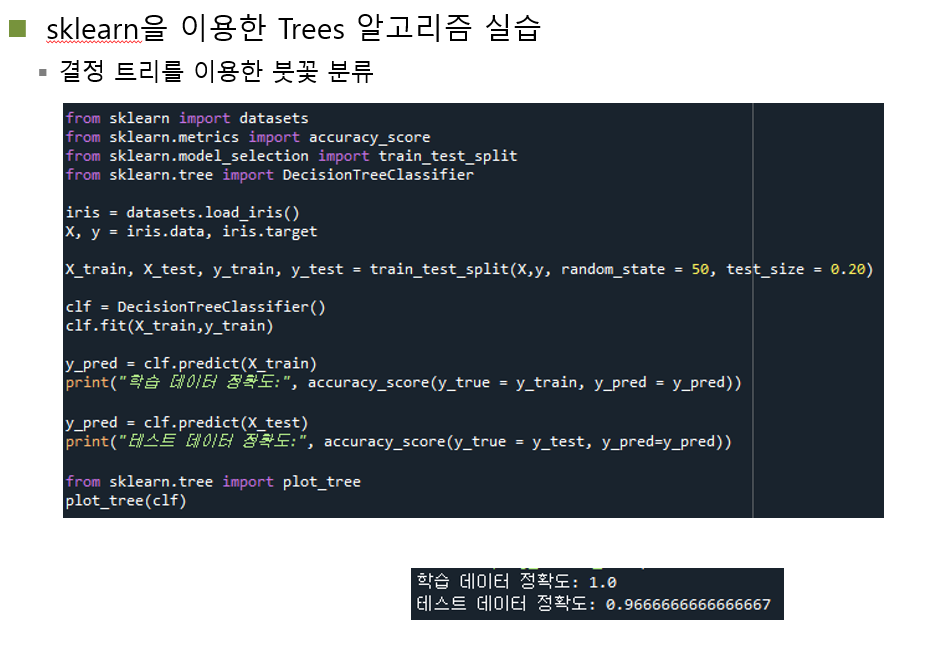

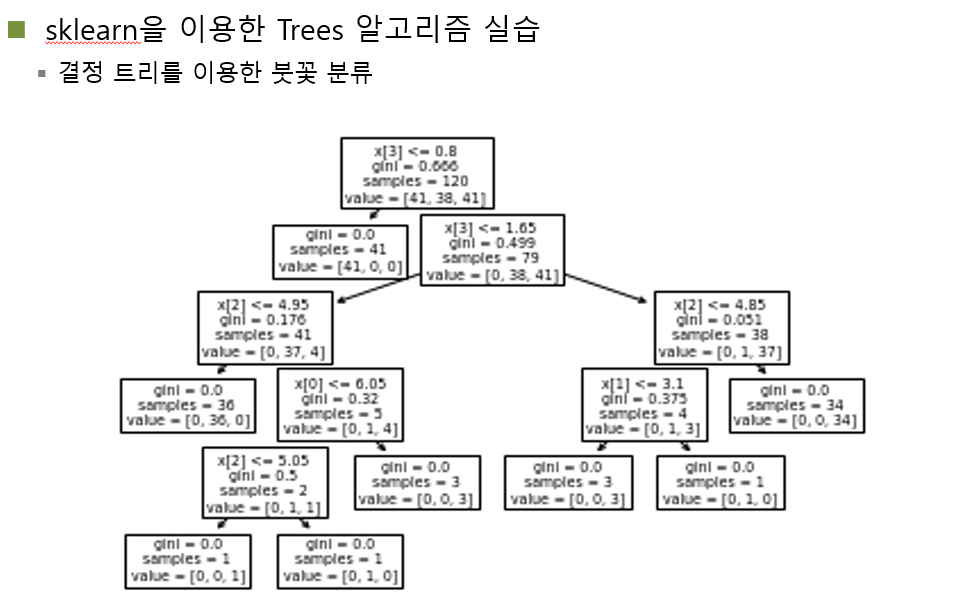

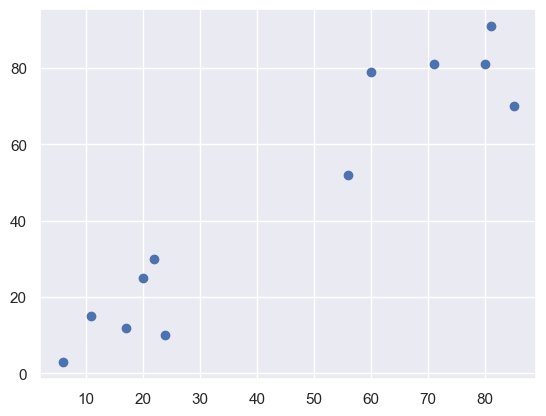

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 2차원 좌표 데이터 12개를 대상으로 KMeans 클러스터링을 수행하고,
# 클러스터링 결과(소속 군집 및 중심 좌표)를 출력한 후,
# 각 점의 군집 결과를 색상으로 시각화하는 예제임.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 2차원 입력 데이터 정의 및 산점도 시각화
# 2단계: KMeans 객체 생성 및 클러스터링 학습 수행
# 3단계: 클러스터 중심 및 라벨 출력
# 4단계: 클러스터링 결과를 색상으로 시각화
# ------------------------------------------------------------

import matplotlib.pyplot as plt  # 시각화 출력을 위한 matplotlib 모듈 임포트
import numpy as np  # 수치 계산 및 배열 생성을 위한 numpy 모듈 임포트
from sklearn.cluster import KMeans  # KMeans 클러스터링 클래스 임포트

X = np.array([
    [6, 3], 
    [11, 15], 
    [17, 12], 
    [24, 10], 
    [20, 25], 
    [22, 30],
    [85, 70], 
    [71, 81], 
    [60, 79], 
    [56, 52], 
    [81, 91], 
    [80, 81]
])
# 입력 데이터 X를 정의 (12개의 2차원 좌표로 구성된 배열)
# 데이터는 명확히 두 개의 군집으로 나뉘는 패턴을 보임

plt.scatter(X[:, 0], X[:, 1])
# 입력 데이터의 산점도를 x축: 첫 번째 열, y축: 두 번째 열 기준으로 시각화
# 초기 군집화 결과를 확인하기 전 기본 분포 구조를 파악하는 용도

[[72.16666667 75.66666667]
 [16.66666667 15.83333333]]
[1 1 1 1 1 1 0 0 0 0 0 0]


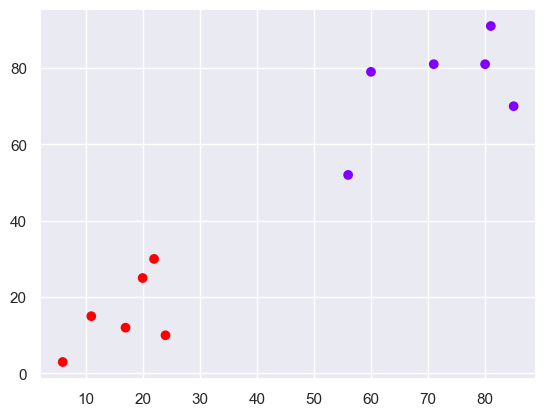

In [35]:
kmeans = KMeans(n_clusters=2)
# KMeans 클러스터링 모델 객체 생성 (군집 수를 2개로 지정)

kmeans.fit(X)
# 전체 입력 데이터 X에 대해 KMeans 알고리즘 학습 수행
# 각 점이 소속될 군집과 군집 중심좌표를 내부적으로 계산

print(kmeans.cluster_centers_)
# 학습된 각 군집의 중심 좌표(centroid)를 출력
# 출력 형태: [[x1, y1], [x2, y2]] (2개의 중심)

print(kmeans.labels_)
# 각 입력 샘플이 소속된 군집 번호(0 또는 1)를 출력
# 출력 형태: [0 0 0 0 0 0 1 1 1 1 1 1] (12개 샘플에 대한 군집 라벨)

plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='rainbow')
# 입력 데이터를 산점도로 다시 출력하되, 각 점의 색상은 클러스터 라벨에 따라 지정
# cmap='rainbow'는 군집별 색상을 명확하게 구분하기 위한 설정

plt.show()
# 최종 산점도 출력 (색상으로 구분된 클러스터링 결과 확인 가능)

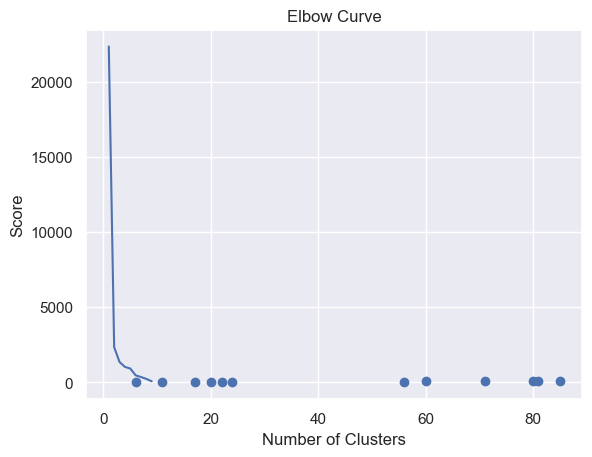

In [37]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 2차원 샘플 데이터에 대해 군집 수(k)를 1부터 9까지 변화시키며  
# 각 군집 수에서의 **KMeans 클러스터링의 inertia(제곱 오차 합)**를 계산하여,  
# 최적의 군집 수를 찾기 위한 **엘보우 기법(Elbow Method)**을 시각화하는 예제임.

# inertia란?
# 각 점이 속한 군집 중심과의 거리 제곱합이며, 작을수록 군집화가 잘 되었다는 의미를 가짐.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 2차원 입력 데이터 정의 및 산점도 출력
# 2단계: 군집 수를 1~9까지 변경하며 KMeans 모델 리스트 생성
# 3단계: 각 모델의 inertia(제곱 오차 합)를 score 리스트에 저장
# 4단계: 군집 수에 따른 inertia 변화 추이를 라인 그래프로 시각화
# ------------------------------------------------------------

import matplotlib.pyplot as plt  # 시각화를 위한 matplotlib 임포트
import numpy as np  # 수치 계산을 위한 numpy 임포트
from sklearn.cluster import KMeans  # KMeans 클러스터링 모델 임포트

# ------------------------------------------------------------
# [1단계] 데이터 정의 및 산점도 출력
# ------------------------------------------------------------

X = np.array([
    [6, 3], 
    [11, 15], 
    [17, 12], 
    [24, 10], 
    [20, 25], 
    [22, 30],
    [85, 70], 
    [71, 81], 
    [60, 79], 
    [56, 52], 
    [81, 91], 
    [80, 81]
])
# 총 12개의 2차원 샘플 좌표를 정의

plt.scatter(X[:, 0], X[:, 1])
# 샘플들을 산점도로 시각화 (초기 데이터 분포 확인 목적)

# ------------------------------------------------------------
# [2단계] KMeans 모델 리스트 생성
# ------------------------------------------------------------

n_clusters = range(1, 10)  
# 실험할 군집 수를 1부터 9까지 지정

kmeans = [KMeans(n_clusters=i, n_init='auto') for i in n_clusters]
# n_clusters의 각 값에 대해 KMeans 모델 객체를 리스트로 생성
# n_init='auto': 초기 중심 선택 횟수를 sklearn이 자동으로 결정

# ------------------------------------------------------------
# [3단계] inertia(제곱 오차합) 계산
# ------------------------------------------------------------

score = [kmeans[i].fit(X).inertia_ for i in range(len(kmeans))]  
# 각 KMeans 모델을 학습시킨 후 inertia(총 제곱 거리 오차)를 리스트에 저장

# ------------------------------------------------------------
# [4단계] Elbow Curve 시각화
# ------------------------------------------------------------

plt.plot(n_clusters, score)  
# 군집 수에 따른 inertia 값을 선 그래프로 출력

plt.xlabel('Number of Clusters')  # x축 라벨 설정
plt.ylabel('Score')               # y축 라벨 설정 (inertia 값)
plt.title('Elbow Curve')          # 그래프 제목 설정

plt.show()  
# 전체 그래프 출력


[3 0 2 0 3 3 1 2 0 0 1 0 2 0 3 2 2 3 1 1 3 3 2 1 1 2 3 2 1 2 0 0 2 0 0 0 0
 0 1 3 2 1 2 2 1 1 0 1 0 3 1 3 0 3 3 1 0 1 0 3 0 2 0 1 1 1 0 3 0 1 2 1 0 1
 1 0 1 2 3 0 3 2 3 3 0 2 3 2 0 0 2 3 0 1 1 2 3 3 2 1 0 3 0 3 2 3 3 2 0 2 1
 1 3 0 3 2 0 3 3 2 1 3 1 3 3 3 3 1 3 1 0 1 1 3 0 1 1 0 2 0 0 1 2 1 2 1 0 2
 0 0 0 2 0 2 3 1 0 1 3 2 0 2 2 3 2 1 1 2 3 2 2 0 3 2 1 0 3 3 2 1 3 2 1 1 2
 2 2 2 3 0 2 1 2 2 1 1 1 2 1 0 2 1 3 1 2 0 1 0 2 0 2 1 2 2 0 1 1 3 3 2 0 3
 3 1 3 1 2 0 0 2 2 0 2 3 1 2 3 1 0 1 3 2 3 0 0 0 0 1 1 0 2 1 3 2 1 1 1 3 3
 0 2 2 1 3 0 1 2 0 2 3 3 1 1 2 3 3 3 2 0 0 3 3 2 3 3 3 0 1 0 2 3 3 0 0 0 3
 3 2 0 1]


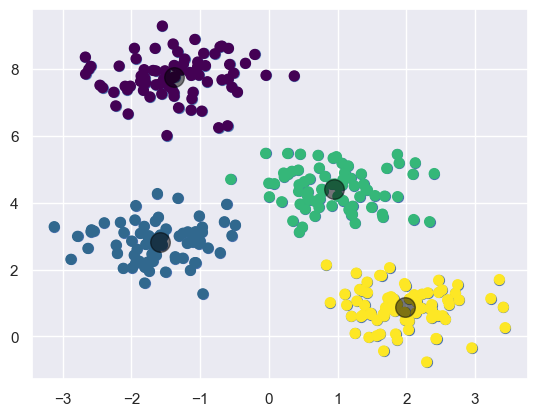

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 sklearn의 `make_blobs`를 이용해 군집 구조를 가진 샘플 데이터를 생성하고,  
# KMeans 클러스터링을 적용하여 군집 예측을 수행한 뒤,  
# 예측된 군집 결과와 군집 중심을 시각화하는 예제임.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 인공 데이터셋 생성 (4개의 중심, 300개 샘플)
# 2단계: 샘플 산점도 시각화
# 3단계: KMeans 클러스터링 수행
# 4단계: 예측된 군집 라벨을 색상으로 시각화
# 5단계: 학습된 군집 중심 표시
# ------------------------------------------------------------

import matplotlib.pyplot as plt  # 시각화 출력을 위한 matplotlib 모듈 임포트
import seaborn as sns; sns.set()  # seaborn 스타일 설정 (시각화 미관 향상)

from sklearn.cluster import KMeans  # KMeans 클러스터링 클래스 임포트
from sklearn.datasets import make_blobs  # 군집 구조 데이터를 생성하기 위한 함수 임포트

# ------------------------------------------------------------
# [1단계] 인공 데이터셋 생성
# ------------------------------------------------------------

X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)
# 총 300개의 2차원 데이터를 4개의 중심점 주변에 생성
# cluster_std=0.60: 클러스터의 퍼짐 정도

# | `cluster_std` 값 | 변화 설명                        | 시각적 특징                 |
# |------------------|-------------------------------|---------------------------|
# | 작을수록         | 각 군집이 좁고 밀집됨            | 군집 간 경계가 명확하고 구분 쉬움     |
# | 클수록           | 각 군집이 넓게 퍼지고 희석됨      | 군집 간 경계가 모호하고 중첩 발생 가능 |

# y_true는 실제 군집 번호이지만 이후 분석에는 사용되지 않음

# ------------------------------------------------------------
# [2단계] 원본 샘플 시각화
# ------------------------------------------------------------

plt.scatter(X[:, 0], X[:, 1], s=50)
# 생성된 2차원 샘플을 산점도로 시각화
# 각 점의 크기는 50으로 설정

# ------------------------------------------------------------
# [3단계] KMeans 클러스터링 수행
# ------------------------------------------------------------

kmeans = KMeans(n_clusters=4)
# KMeans 객체 생성, 군집 수를 4개로 설정

kmeans.fit(X)
# 생성된 데이터 X를 사용하여 KMeans 클러스터링 모델 학습

y_kmeans = kmeans.predict(X)
# 학습된 모델을 이용해 각 샘플이 속할 군집 라벨을 예측
# y_kmeans는 각 샘플의 군집 번호 배열 (0~3)

print(y_kmeans)
# 각 데이터 포인트가 속한 군집 번호 출력

# ------------------------------------------------------------
# [4단계] 군집 결과 시각화
# ------------------------------------------------------------

plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
# 각 샘플을 군집 라벨에 따라 다른 색으로 시각화
# cmap='viridis'는 시각적으로 구분이 잘 되는 색상 맵 사용

# ------------------------------------------------------------
# [5단계] 군집 중심 시각화
# ------------------------------------------------------------

centers = kmeans.cluster_centers_
# 각 군집의 중심 좌표를 추출 (shape: [4, 2])

plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)
# 각 중심 좌표를 검은색, 크기 200, 투명도 0.5로 시각화하여 강조

plt.show()
# 전체 결과를 시각적으로 출력


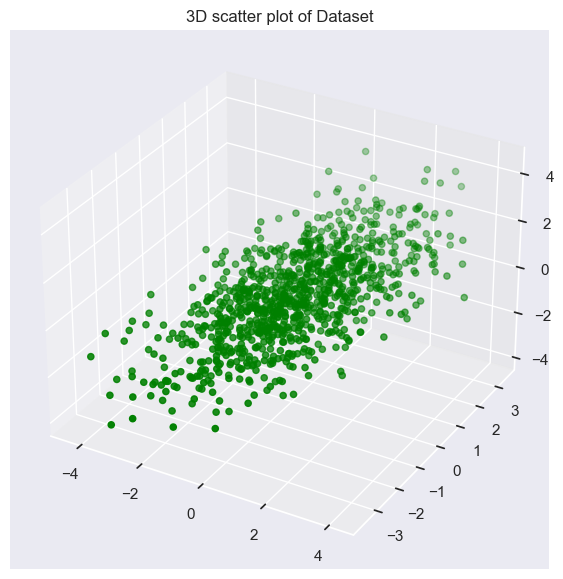

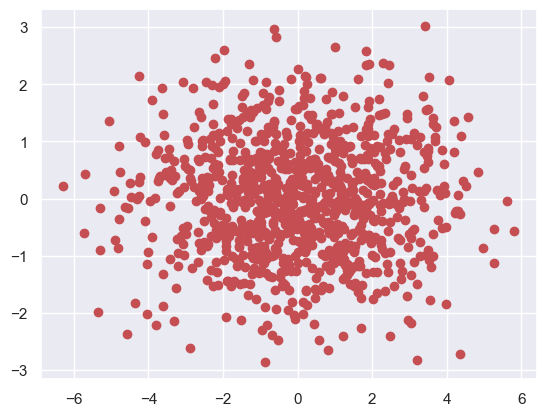

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 3차원 공간에 특정한 선형 구조를 갖는 데이터셋을 생성하고,
# sklearn의 PCA(주성분 분석)를 이용하여 해당 데이터를 2차원으로 축소한 뒤,
# 원본과 축소된 데이터를 각각 시각화하는 실습 예제임.

# 차원 축소에는 두 가지 방법이 있음:

# 특징 선택(Feature Selection): 중요하지 않은 기존 특성을 제거

# 특징 추출(Feature Extraction): 기존 특성들을 조합해 새로운 축으로 변환
# 예: PCA, Autoencoder

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 3차원 데이터셋 생성 (선형 조합 기반)
# 2단계: 3D 산점도 시각화
# 3단계: PCA 모델 학습 및 차원 축소
# 4단계: 2D 산점도 시각화
# ------------------------------------------------------------

import numpy as np  # 수치 계산 및 난수 생성 등을 위한 numpy 모듈 임포트
import matplotlib.pyplot as plt  # 시각화를 위한 matplotlib 모듈 임포트

u = np.array([1, 1, 1]) / np.sqrt(3)  
# 벡터 u 정의: (1,1,1) 방향 벡터를 단위벡터로 정규화
# 데이터가 주로 놓일 저차원 공간의 주축 역할 수행

v = np.array([1, 0, -1]) / np.sqrt(2)  
# 벡터 v 정의: (1,0,-1) 방향 벡터를 단위벡터로 정규화
# u와 독립적인 다른 방향을 구성함

# ------------------------------------------------------------
# [1단계] 데이터 생성
# ------------------------------------------------------------

n_data = 1000  # 생성할 데이터 샘플 수를 1000개로 설정
X = []  # 데이터셋을 저장할 빈 리스트 정의

for _ in range(n_data):
    r_coeff = np.random.randn(2,)  
    # 평균 0, 표준편차 1인 정규분포를 따르는 2차원 난수 생성
    data = 2.0 * r_coeff[0] * u + r_coeff[1] * v + 0.1 * np.random.rand(3,)  
    # 생성된 난수를 u, v에 선형 결합하여 데이터 생성
    # 마지막 항은 노이즈 항으로 작은 무작위성을 추가
    X.append(data)  # 생성된 3차원 데이터를 리스트에 저장

X = np.array(X)  
# 리스트를 numpy 배열로 변환하여 후속 연산 가능하도록 처리

# ------------------------------------------------------------
# [2단계] 3D 데이터 시각화
# ------------------------------------------------------------

fig = plt.figure(figsize=(10, 7))  
# 3D 그래프 출력을 위한 matplotlib figure 생성

ax = plt.axes(projection="3d")  
# 3차원 공간 상에 그래프를 그리기 위한 Axes3D 객체 생성

ax.scatter3D(X[:, 0], X[:, 1], X[:, 2], color="green")  
# 3차원 데이터 X의 각 축에 해당하는 값을 산점도로 시각화

plt.title("3D scatter plot of Dataset")  # 그래프 제목 설정
plt.show()  # 3D 그래프 출력

# ------------------------------------------------------------
# [3단계] PCA 차원 축소
# ------------------------------------------------------------

from sklearn.decomposition import PCA  # PCA 모델 임포트

pca = PCA(n_components=2)  
# 주성분 개수를 2개로 설정하여 3차원 데이터를 2차원으로 축소

X_2d_sklearn = pca.fit_transform(X)  
# PCA 학습과 동시에 X 데이터에 대해 차원 축소 수행
# 반환값은 2차원 좌표로 변환된 새로운 데이터

# ------------------------------------------------------------
# [4단계] 2D 차원 축소 결과 시각화
# ------------------------------------------------------------

plt.scatter(X_2d_sklearn[:, 0], X_2d_sklearn[:, 1], color='r')  
# 차원 축소된 데이터를 2D 산점도로 출력

plt.title("2D PCA projection")  # 2차원 PCA 결과 제목 설정
plt.show()  # 그래프 출력


> 행렬과 특잇값에 대한 요약 정리

| 질문 | 설명 |
|------|-----------|
| 행렬은 단순히 데이터일 뿐 아닌가요? | ❌ 행렬은 벡터를 변형하는 수학적 도구. |
| 행렬은 어떻게 벡터를 변형하나요? | 기존에 있던 벡터와 행렬이 곱해질 때 이 행렬은 기존에 있던 벡터의 방향을 회전시키고, 길이를 늘이거나 줄이는 효과를 냄. |
| 행렬이 벡터를 늘이거나 줄인다는 건 무슨 뜻인가요? | 특정 방향의 벡터를 행렬이 얼마나 강하게 확대 또는 축소하는지를 의미. |
| 특잇값은 어떤 역할을 하나요? | 행렬이 각 방향에 대해 얼마만큼 정보를 보존하거나 줄이는지를 수치로 표현한 값. |
| 특잇값은 왜 중요하죠? | 큰 특잇값은 중요한 정보 방향을 의미하며, 작은 특잇값은 압축하거나 버려도 되는 방향. |
| 행렬은 언제 변형을 일으키나요? | 오직 벡터와 곱해질 때! (행렬 × 벡터 → 변형된 벡터) |

> 🎯 **중요한 건** 행렬은 단순히 숫자가 들어 있는 표처럼 보여도,  
> 실제로는 벡터의 **크기와 방향을 바꾸는 도구**라는 점입니다.


| 개념 | 설명 |
|------|------|
| 특잇값(Singular Value) | 행렬이 특정 방향의 벡터를 얼마나 "늘이거나 줄이는지" 나타내는 값 |
| 크기가 클수록 | 정보가 많이 담긴 중요 축 |
| 크기가 작을수록 | 덜 중요한 방향 → 압축 대상 |
| PCA에서 역할 | 주성분의 분산 크기와 연결됨 |


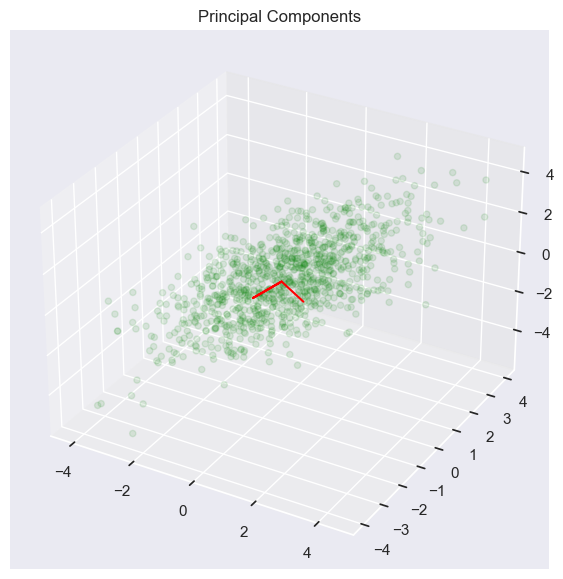

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 앞서 생성한 3차원 데이터에 대해,
# PCA를 직접 수학적으로 구현하기 위해 SVD(특이값 분해)를 활용하여  
# 주성분 벡터를 계산하고, 이를 시각적으로 확인한 뒤,  
# 주성분 평면으로 데이터를 투영하여 차원 축소 결과를 시각화하는 예제임.

# | 개념 | 쉬운 말로 |
# |------|------------|
# | **SVD** | 복잡한 변환을 3단계로 나누는 방법 (회전 → 크기 조절 → 회전) |
# | **어디에 써?** | 차원 축소, 추천 시스템, 이미지 압축, 텍스트 분석 등 |
# | **왜 써?** | 데이터를 더 잘 이해하고, 효율적으로 처리하기 위해서 |

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 평균 중심화 → 데이터를 원점 중심으로 이동
# 2단계: SVD(특이값 분해) → 주성분 벡터 획득
# 3단계: 원래 데이터와 주성분 방향을 3D 시각화
# 4단계: 데이터 → 주성분 평면으로 투영 → 2차원 시각화
# ------------------------------------------------------------

# ------------------------------------------------------------
# [1단계] 평균 중심화
# ------------------------------------------------------------

X_adj = X - X.mean(axis=0)  
# 데이터의 평균을 각 열마다 구한 후, 전체 데이터에서 평균을 빼줌
# → 데이터를 원점(0,0,0)을 중심으로 재배치하여 주성분 분석의 기반 마련

# ------------------------------------------------------------
# [2단계] SVD로 주성분 계산
# ------------------------------------------------------------

U, S, Vt = np.linalg.svd(X_adj)  
# SVD(특이값 분해)를 수행하여
# X_adj = U * S * Vt 로 분해
# Vt: 주성분이 행(row)으로 정리된 직교 행렬

Vt.T  
#  PCA에서 Vt(또는 Vt.T)는 가장 중요한 정보, 
# 즉 "데이터를 가장 잘 설명하는 축(=주성분 방향 벡터들)"을 담고 있는 행렬
# Vt의 전치 행렬은 주성분들을 열벡터 형태로 나타냄
# → 주성분 방향들을 3차원 공간 내 방향 벡터로 사용 가능

# ------------------------------------------------------------
# [3단계] 3차원 공간에 주성분 벡터 시각화
# ------------------------------------------------------------

fig = plt.figure(figsize=(10, 7))  
# 시각화를 위한 figure 객체 생성

ax = plt.axes(projection="3d")  
# 3D 좌표축 생성

ax.scatter3D(X[:, 0], X[:, 1], X[:, 2], color="green", alpha=0.1)  
# 원래 3차원 데이터 X를 흐리게 출력 (배경 시각화 용도)

plt.title("Principal Components")  
# 그래프 제목 설정

origin = np.zeros((1, 3))  
# (0,0,0) 원점 좌표 정의

# 주성분 벡터를 선으로 그리기 위한 좌표 생성
# origin → 주성분1 → origin → 주성분2 로 이어지는 좌표 배열 생성
# [원점 → PC1] 선, [원점 → PC2] 선을 차례로 그릴 수 있도록 **4개의 점을 담은 배열 C**를 만든 것
# 결과적으로 C는 (4, 3) 크기의 2차원 배열
C = np.concatenate((
    origin,              # [0,0,0] → 첫 번째 선의 시작점 # shape (1, 3)
    Vt[0, :].reshape(-1, 3),  # PC1 벡터 방향 → 첫 번째 선의 끝점 # shape (1, 3)

    origin,              # [0,0,0] → 두 번째 선의 시작점 # shape (1, 3)
    Vt[1, :].reshape(-1, 3)   # PC2 벡터 방향 → 두 번째 선의 끝점 # shape (1, 3)
), axis=0)

ax.plot3D(C[:, 0], C[:, 1], C[:, 2], color="red")  
# 3차원 공간에 주성분 벡터(PC1, PC2)를 빨간 선으로 출력
# 원래 3D 공간에서 데이터가 어디로 분산되어 있는지를 설명하는 
# 주성분 방향(PC1, PC2)**을 3차원 공간 위에 "벡터"로 시각화하는 단계이기 때문에
# x, y, z가 필요

plt.show()  
# 3D 그래프 출력

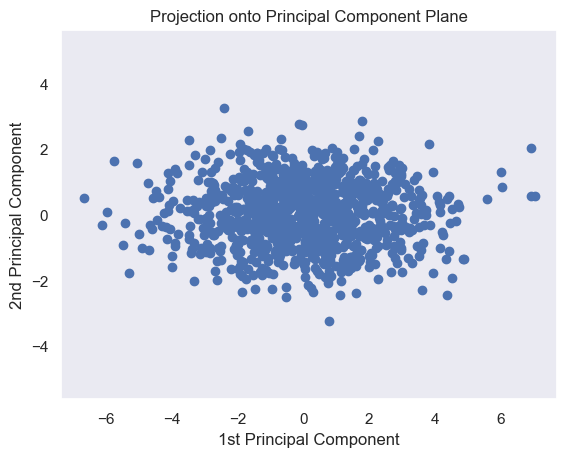

In [57]:
# ------------------------------------------------------------
# [4단계] 데이터 → 주성분 평면으로 투영 (차원 축소)
# ------------------------------------------------------------

W_2d = Vt.T[:, :2]  
# 주성분 행렬의 앞 두 개 벡터(PC1, PC2)를 선택하여 투영 행렬 생성
# Vt.T는 (3x3), → [:, :2]는 (3x2), 즉 3차원 데이터를 2차원으로 줄이는 투영 행렬

X_2d = X_adj.dot(W_2d)  
# 평균 중심화된 데이터를 주성분 평면에 투영하여 2차원 좌표로 변환

plt.scatter(X_2d[:, 0], X_2d[:, 1])  
# 차원 축소된 데이터의 2D 산점도 출력

plt.title("Projection onto Principal Component Plane")  
plt.xlabel("1st Principal Component")  
plt.ylabel("2nd Principal Component")  
plt.grid()
plt.axis('equal')
plt.show()  
# 2차원 그래프 출력

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 sklearn에서 제공하는 붓꽃(Iris) 데이터셋을 로드한 뒤,
# 각 특성(feature) 값과 정답(target) 라벨을 결합하여,
# pandas의 DataFrame으로 변환하고, 그 결과를 출력하는 예제임.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 필요한 라이브러리 임포트
# 2단계: 붓꽃 데이터셋 로드
# 3단계: 데이터와 라벨을 결합하여 pandas DataFrame 구성
# 4단계: 구성된 DataFrame 출력
# ------------------------------------------------------------

import numpy as np  # 수치 연산 및 배열 결합을 위한 numpy 모듈 임포트
import pandas as pd  # 데이터프레임 처리를 위한 pandas 모듈 임포트
import matplotlib.pyplot as plt  # 시각화를 위한 matplotlib 모듈 임포트
from sklearn.datasets import load_iris  # 붓꽃 데이터셋 로딩 함수 임포트

iris = load_iris()  
# sklearn의 붓꽃(Iris) 데이터셋을 로드하여 변수에 저장
# iris 객체는 딕셔너리 구조로 구성되어 있으며,
# 'data'는 특성 값, 'target'은 품종 번호, 'feature_names'는 특성 이름을 포함함

df = pd.DataFrame(
    data=np.c_[iris['data'], iris['target']],  
    # np.c_: axis=1으로 특성과 정답 배열을 결합
    columns=iris['feature_names'] + ['target']  
    # 각 열에 대한 이름 설정 (꽃받침/꽃잎 길이·너비 + target)
)
# → 총 150개의 샘플, 5개의 열(column)을 가진 DataFrame이 생성됨

print(df)  
# 생성된 pandas DataFrame을 표 형태로 출력


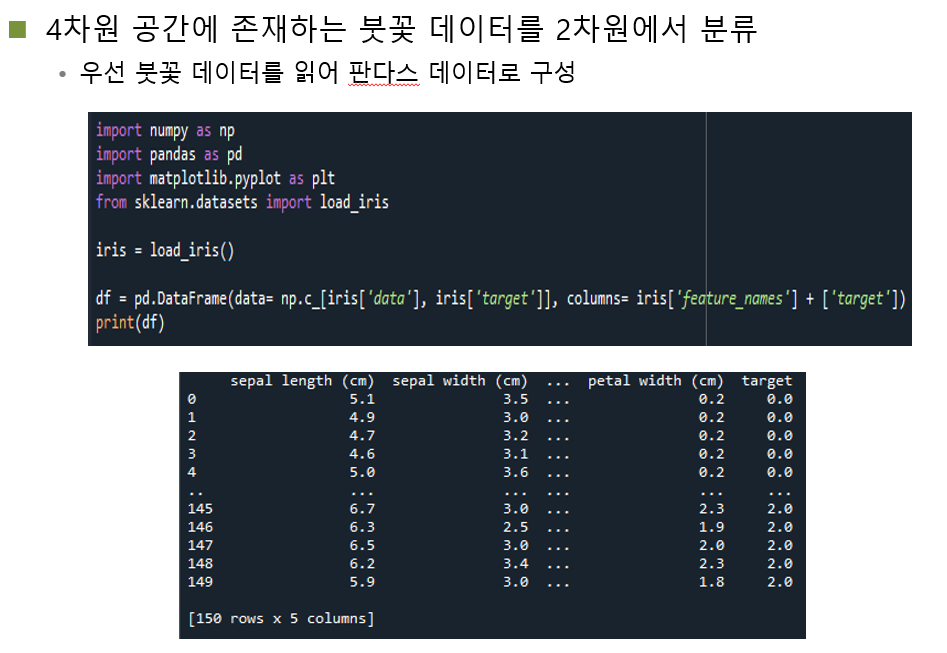

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 붓꽃(iris) 데이터셋에서 특성(feature) 값들을 추출한 후,  
# 각 특성별로 평균 0, 표준편차 1이 되도록 **표준화 전처리(StandardScaler)**를 수행하는 예제임.  
# 이는 PCA, KNN, 거리 기반 모델 등에 필요한 전처리 단계임.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 필요한 모듈 임포트 및 특성명 추출
# 2단계: 특성과 라벨 데이터를 numpy 배열로 분리
# 3단계: 특성 데이터에 대해 표준화 수행
# ------------------------------------------------------------

from sklearn.preprocessing import StandardScaler  # 표준화 클래스 임포트

features = iris['feature_names']  
# 특성(컬럼) 이름을 리스트 형태로 추출
# 예: ['sepal length (cm)', 'sepal width (cm)', ...]

print(features)  
# 추출한 특성 이름 출력

# ------------------------------------------------------------
# [2단계] 데이터 분리
# ------------------------------------------------------------

X = df.loc[:, features].values  
# DataFrame에서 특성 컬럼들만 추출하여 numpy 배열로 변환
# → shape: (150, 4)

y = df.loc[:, ['target']].values  
# 'target' 컬럼을 별도로 추출하여 정답 배열로 저장
# → shape: (150, 1)

# ------------------------------------------------------------
# [3단계] 표준화 수행
# ------------------------------------------------------------

X = StandardScaler().fit_transform(X)  
# X 데이터에 대해 평균을 0, 표준편차를 1로 조정하는 표준화 전처리 수행
# StandardScaler 객체를 생성하고, fit(통계 계산) 후 transform(변환)을 동시에 적용

print(X)  
# 표준화된 특성 값 출력
# 출력 형태는 (150, 4)이며, 각 특성의 평균은 0, 표준편차는 1에 가까움


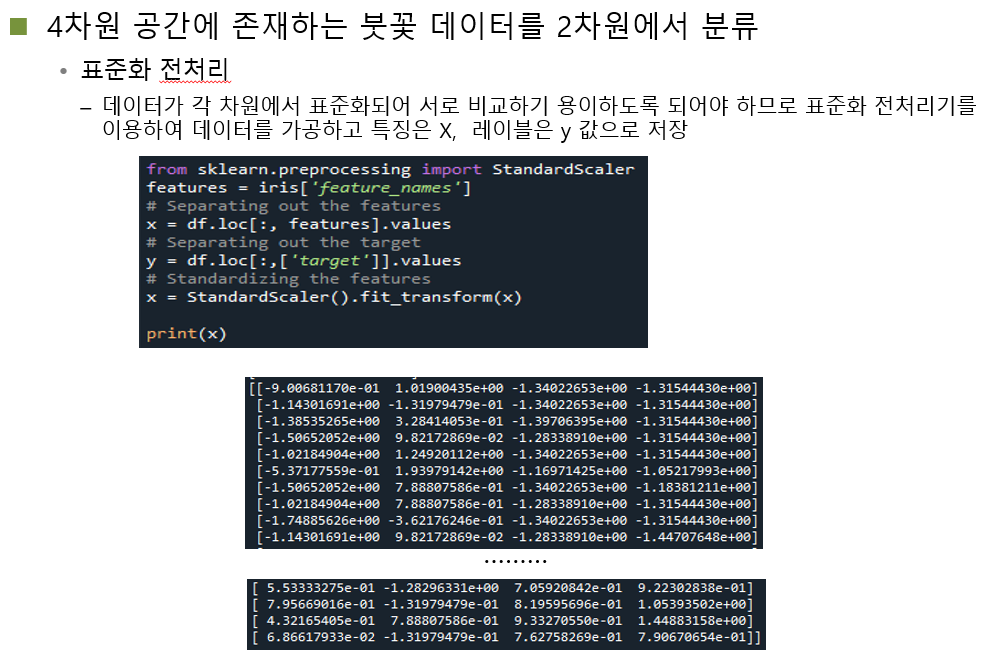

| 용어 / 함수 | 설명 |
|--------------|------|
| `StandardScaler()` | 각 특성을 평균 0, 표준편차 1로 변환 |
| `fit_transform()` | 표준화 기준(평균, 표준편차)을 계산하고 적용 |
| `df.loc[:, features]` | 모든 행에서 특정 열(features)만 추출 |
| `.values` | pandas DataFrame → numpy 배열 변환 |


✅ 표준화가 필요한 이유

| 이유 | 설명 |
|------|------|
| 거리 기반 모델에 민감 | PCA, KMeans, SVM 등은 특성 간 거리 계산에 기반하므로 스케일 차이에 민감함 |
| 특정 특성의 영향력 왜곡 | 값 범위가 큰 칼럼(Feature) 값이 모델 학습에서 과도한 영향력을 가질 수 있음 |
| 특성 간 영향력 균형 조정 | 표준화를 통해 모든 칼럼(Feature)의 값의 범위가 동일한 척도로 반영되도록 만듦 |


✔️ 표준화는 "행(row)"이 아니라 "열(column)"에 대해 수행.

→ 데이터의 각 Feature 축마다 따로 평균과 표준편차를 구해 표준화 하는 것

(피처 벡터는 하나의 샘플이 가진 모든 피처 값들을 묶은 벡터이며, 이는 행(row)에 해당)

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 표준화된 붓꽃(iris) 데이터셋에 PCA(주성분 분석)를 적용하여  
# 고차원(4차원) 특성 데이터를 **2차원 공간(PC1, PC2)** 으로 축소하고,  
# PCA 결과와 기존 라벨(target)을 결합하여 시각화 및 분석이 가능한 구조의 DataFrame을 생성하는 예제임.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: PCA 모델 생성 및 2차원으로 차원 축소
# 2단계: 주성분 결과를 DataFrame으로 변환
# 3단계: 기존 target 라벨과 결합하여 최종 DataFrame 생성
# ------------------------------------------------------------

from sklearn.decomposition import PCA  # PCA 클래스 임포트

pca = PCA(n_components=2)  
# 주성분 개수를 2개로 설정하여 PCA 모델 객체 생성

# 사이킷런의 PCA 클래스는 내부적으로 특잇값 분해(SVD, Singular Value Decomposition)를 사용
pca_result = pca.fit_transform(X)  
# 표준화된 특성 행렬 X에 대해 PCA를 수행하여 2차원으로 축소
# 반환값은 shape = (150, 2)이며, 각 행은 (PC1, PC2) 좌표를 의미

principalDf = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])  
# PCA 결과를 pandas DataFrame으로 변환
# 'PC1', 'PC2'라는 이름의 컬럼으로 구성됨

principalDf, df['target']  
# → 두 객체를 나란히 출력하려는 의도이지만, 출력 코드로는 작동하지 않음
# 해당 줄은 의미가 없으므로 제거 또는 주석 처리 권장

finalDf = pd.concat([principalDf, df[['target']]], axis=1)  
# PCA 결과 DataFrame과 기존 붓꽃 품종 라벨을 좌우 방향(axis=1)으로 결합
# 최종 결과는 (150, 3) 형태의 DataFrame: PC1, PC2, target

print(finalDf)  
# 최종 PCA+라벨 통합 데이터프레임을 출력


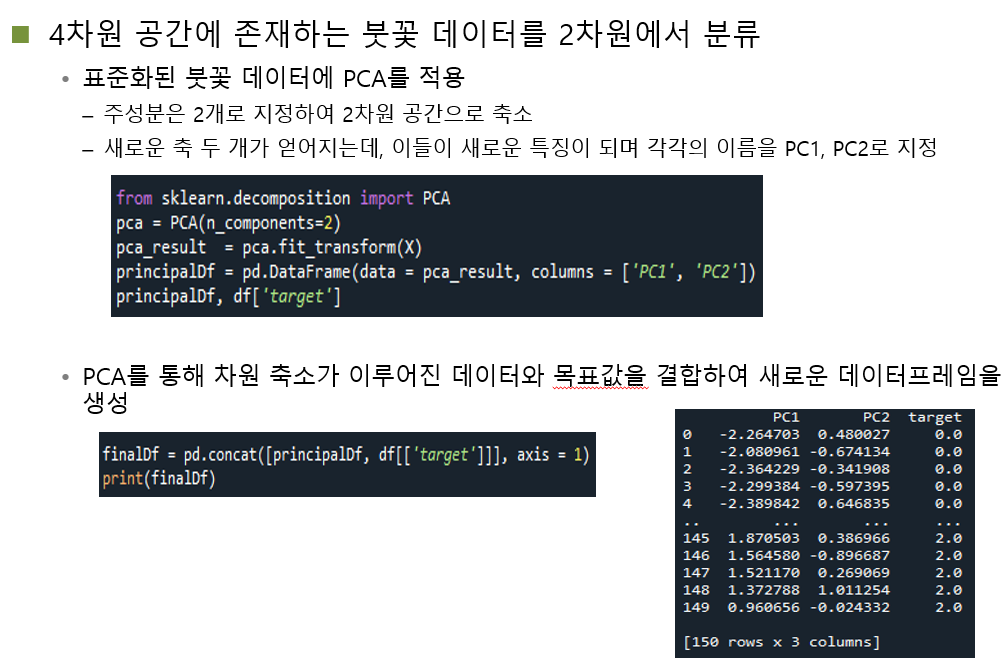

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 이전에 PCA를 통해 2차원으로 축소된 붓꽃(iris) 데이터를  
# 품종별로 색깔을 다르게 하여 산점도로 시각화하는 예제임.  
# 주성분 축(PC1, PC2)을 기반으로 분포된 데이터를 통해  
# 품종 간 구분이 어떻게 가능한지를 직관적으로 확인할 수 있음.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 시각화용 figure 및 축 설정
# 2단계: 품종(target)에 따라 색상 다르게 점 찍기
# 3단계: 범례와 격자 설정
# ------------------------------------------------------------

fig = plt.figure(figsize=(5, 5))  
# 그래프 크기를 5x5로 설정한 figure 객체 생성

ax = fig.add_subplot(1, 1, 1)  
# 1행 1열 1개의 subplot을 생성하고 그 축을 ax에 저장

ax.set_xlabel('Primary Principal Component')  
# x축 라벨을 'PC1' 대신 설명적인 이름으로 설정

ax.set_ylabel('Secondary Principal Component')  
# y축 라벨을 'PC2' 대신 설명적인 이름으로 설정

ax.set_title('Dimension Reduction with PCA', fontsize=20)  
# 그래프 제목을 설정하고 글꼴 크기를 20으로 지정

targets = [0.0, 1.0, 2.0]  
# 붓꽃 데이터셋의 세 가지 품종 라벨 (정수형이지만 float형으로 저장된 상태)

colors = ['r', 'g', 'b']  
# 각 품종에 매핑할 색상 지정 (빨강, 초록, 파랑)

# ------------------------------------------------------------
# [2단계] 품종별로 점 찍기
# ------------------------------------------------------------
for target, color in zip(targets, colors):
    idx = finalDf['target'] == target  
    # target 라벨에 해당하는 행만 선택하기 위한 불리언 인덱싱
    
    ax.scatter(
        finalDf.loc[idx, 'PC1'],  
        # 해당 target 그룹의 PC1 값 추출
        
        finalDf.loc[idx, 'PC2'],  
        # 해당 target 그룹의 PC2 값 추출
        
        c=color,  # 색상 설정
        label=iris.target_names[int(target)]  # 범례 항목용 라벨 추가 (옵션)
    )

# ------------------------------------------------------------
# [3단계] 범례 및 격자 출력
# ------------------------------------------------------------
ax.legend(targets)  
# 범례 출력 (단, 더 나은 표현은 위에서 label을 품종명으로 지정하는 것)

ax.grid()  
# 축의 격자 표시


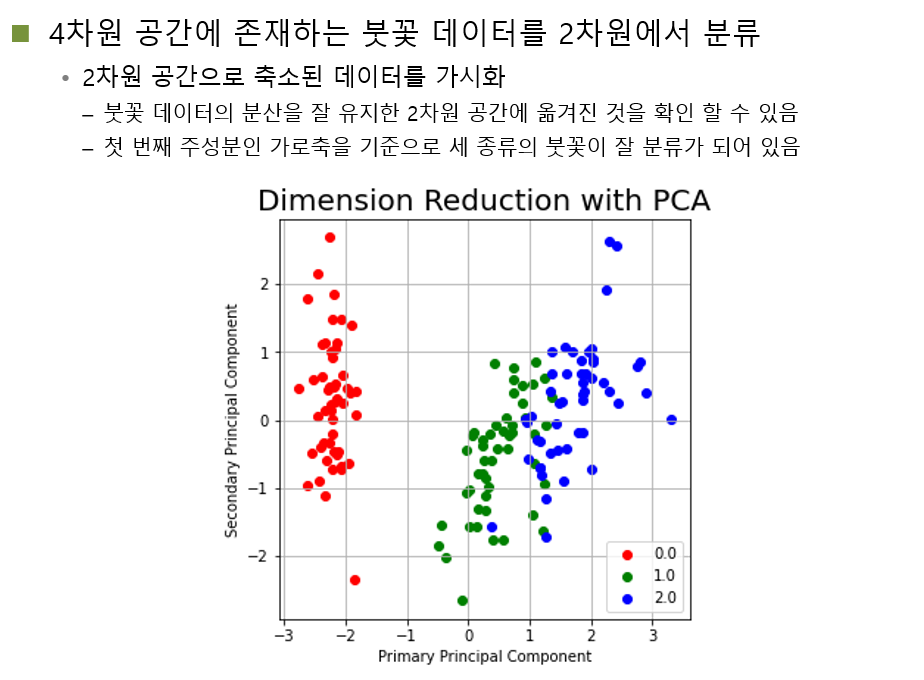